<a href="https://colab.research.google.com/github/atletisimo/-_-_-/blob/main/benign_threat_PART1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os
import networkx as nx
path = kagglehub.dataset_download("aryan208/cybersecurity-threat-detection-logs")

100%|██████████| 95.7M/95.7M [00:05<00:00, 17.3MB/s]

Extracting files...


ИМПОРТИРАЊЕ НА ПОТРЕБНИТЕ БИБЛИОТЕКИ

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import networkx as nx
from networkx import pagerank
import matplotlib.pyplot as plt


from sklearn.semi_supervised import LabelPropagation

LOADING AND PREPROCESSING DATA

In [ ]:

print("=" * 80)
print("LOADING AND PREPROCESSING DATA")
print("=" * 80)

csv_file = os.path.join(path, "cybersecurity_threat_detection_logs.csv")
df = pd.read_csv(csv_file)


print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
print(df.info())


df['timestamp'] = pd.to_datetime(df['timestamp'])

print("\nTimestamp converted:")
display(df[['timestamp']].head())


unique_ips = pd.concat([df['source_ip'], df['dest_ip']]).unique()

print(f"\nTotal unique IPs: {len(unique_ips)}")
print("Example IPs:", unique_ips[:5])

# 0 = Normal (Benign)
# 1 = Threat (Suspicious + Malicious)

threat_label_mapping = {
    "benign": 0,
    "suspicious": 1,
    "malicious": 1
}

df["threat_label"] = df["threat_label"].map(threat_label_mapping)

print("\nBinary label distribution:")
print(df["threat_label"].value_counts())

# Check for errors
if df["threat_label"].isnull().any():
    raise ValueError("Unknown values found in threat_label!")




le = LabelEncoder()

categorical_columns = [
    "protocol",
    "action",
    "log_type",
    "user_agent",
    "request_path"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        print(f"{col} encoded.")



X = df.drop("threat_label", axis=1)
y = df["threat_label"] #target

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nBinary class distribution:")
print(y.value_counts())

#podelba na train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain/Test Split")
print("-----------------------------")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

LOADING AND PREPROCESSING DATA

Number of rows: 6000000
Number of columns: 10

First 5 rows:


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01T00:00:00,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18T00:00:00,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07T00:00:00,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login
3,2024-10-26T00:00:00,192.168.1.236,192.168.1.219,HTTP,allowed,benign,application,5350,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,/login
4,2024-10-31T00:00:00,192.168.1.221,192.168.1.61,ICMP,allowed,benign,application,40691,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000000 entries, 0 to 5999999
Data columns (total 10 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   timestamp          object
 1   source_ip          object
 2   dest_ip            object
 3   protocol           object
 4   action             object
 5   threat_label       object
 6   log_type           object
 7   bytes_transferred  int64 
 8   user_agent         object
 9   request_path       object
dtypes: int64(1), object(9)
memory usage: 457.8+ MB
None

Timestamp converted:


,timestamp
0,2024-05-01
1,2024-07-18
2,2024-04-07
3,2024-10-26
4,2024-10-31



Total unique IPs: 354
Example IPs: ['192.168.1.125' '192.168.1.201' '192.168.1.248' '192.168.1.236'
 '192.168.1.221']

Binary label distribution:
threat_label
0    5517611
1     482389
Name: count, dtype: int64
protocol encoded.
action encoded.
log_type encoded.
user_agent encoded.
request_path encoded.

Feature shape: (6000000, 9)
Target shape: (6000000,)

Binary class distribution:
threat_label
0    5517611
1     482389
Name: count, dtype: int64

Train/Test Split
-----------------------------
Training samples: 4800000
Testing samples: 1200000

Training distribution:
threat_label
0    4414089
1     385911
Name: count, dtype: int64

Testing distribution:
threat_label
0    1103522
1      96478
Name: count, dtype: int64


ГРАДЕЊЕ ГРАФ И ВАДЕЊЕ НА ГРАФ БАЗИРАНИТЕ КАРАКТЕРИСТИКИ

In [ ]:

print("Grouping data to create weighted edges...")
edges_df = df.groupby(['source_ip', 'dest_ip']).size().reset_index(name='weight')

G = nx.DiGraph()
print("Building the directed graph...")
for _, row in edges_df.iterrows():
    G.add_edge(row['source_ip'], row['dest_ip'], weight=row['weight'])

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

print("Calculating graph features...")

# Degree, In-Degree, Out-Degree (unweighted)
degree_map = dict(G.degree())
in_degree_map = dict(G.in_degree())
out_degree_map = dict(G.out_degree())

# Weighted Degree
weighted_degree_map = dict(G.degree(weight='weight'))

# PageRank
pagerank_map = nx.pagerank(G)

# Betweenness Centrality

print("Calculating Betweenness Centrality...")
betweenness_map = nx.betweenness_centrality(G)
print("Betweenness Centrality calculated.")

# Closeness Centrality
print("Calculating Closeness Centrality...")
closeness_map = nx.closeness_centrality(G)
print("Closeness Centrality calculated.")

# Helper function
def get_feature(ip, feature_map):
    return feature_map.get(ip, 0.0)

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

#train
print("Adding graph features to X_train...")
X_train_processed['source_ip_degree'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, degree_map))
X_train_processed['source_ip_in_degree'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, in_degree_map))
X_train_processed['source_ip_out_degree'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, out_degree_map))
X_train_processed['source_ip_weighted_degree'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, weighted_degree_map))
X_train_processed['source_ip_pagerank'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, pagerank_map))
X_train_processed['source_ip_betweenness'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, betweenness_map))
X_train_processed['source_ip_closeness'] = X_train_processed['source_ip'].apply(lambda ip: get_feature(ip, closeness_map))

X_train_processed['dest_ip_degree'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, degree_map))
X_train_processed['dest_ip_in_degree'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, in_degree_map))
X_train_processed['dest_ip_out_degree'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, out_degree_map))
X_train_processed['dest_ip_weighted_degree'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, weighted_degree_map))
X_train_processed['dest_ip_pagerank'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, pagerank_map))
X_train_processed['dest_ip_betweenness'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, betweenness_map))
X_train_processed['dest_ip_closeness'] = X_train_processed['dest_ip'].apply(lambda ip: get_feature(ip, closeness_map))

#test
print("Adding graph features to X_test...")
X_test_processed['source_ip_degree'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, degree_map))
X_test_processed['source_ip_in_degree'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, in_degree_map))
X_test_processed['source_ip_out_degree'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, out_degree_map))
X_test_processed['source_ip_weighted_degree'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, weighted_degree_map))
X_test_processed['source_ip_pagerank'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, pagerank_map))
X_test_processed['source_ip_betweenness'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, betweenness_map))
X_test_processed['source_ip_closeness'] = X_test_processed['source_ip'].apply(lambda ip: get_feature(ip, closeness_map))

X_test_processed['dest_ip_degree'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, degree_map))
X_test_processed['dest_ip_in_degree'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, in_degree_map))
X_test_processed['dest_ip_out_degree'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, out_degree_map))
X_test_processed['dest_ip_weighted_degree'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, weighted_degree_map))
X_test_processed['dest_ip_pagerank'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, pagerank_map))
X_test_processed['dest_ip_betweenness'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, betweenness_map))
X_test_processed['dest_ip_closeness'] = X_test_processed['dest_ip'].apply(lambda ip: get_feature(ip, closeness_map))

X_train = X_train_processed
X_test = X_test_processed

print("Graph-based features successfully added to X_train and X_test.")
display(X_train.head())
display(X_test.head())

Grouping data to create weighted edges...
Building the directed graph...
Graph created with 354 nodes and 89916 edges.
Calculating graph features...
Calculating Betweenness Centrality...
Betweenness Centrality calculated.
Calculating Closeness Centrality...
Closeness Centrality calculated.
Adding graph features to X_train...
Adding graph features to X_test...
Graph-based features successfully added to X_train and X_test.


,timestamp,source_ip,dest_ip,protocol,action,log_type,bytes_transferred,user_agent,request_path,source_ip_degree,...,source_ip_pagerank,source_ip_betweenness,source_ip_closeness,dest_ip_degree,dest_ip_in_degree,dest_ip_out_degree,dest_ip_weighted_degree,dest_ip_pagerank,dest_ip_betweenness,dest_ip_closeness
1853046,2024-10-05,61.72.172.125,192.168.1.7,6,0,0,27840,2,0,254,...,0.000424,0.0,0.0,608,354,254,40289,0.003753,0.0,1.0
1152808,2024-08-24,192.168.1.95,192.168.1.35,1,1,1,1037,3,96,608,...,0.003800,0.0,1.0,608,354,254,40151,0.003783,0.0,1.0
5197696,2024-12-29,68.36.64.191,192.168.1.248,3,0,1,28031,1,0,254,...,0.000424,0.0,0.0,608,354,254,40439,0.003835,0.0,1.0
901055,2024-05-04,192.168.1.1,192.168.1.30,5,1,1,20901,0,0,608,...,0.003763,0.0,1.0,608,354,254,40055,0.003763,0.0,1.0
4365743,2024-12-07,192.168.1.37,192.168.1.100,6,1,2,48941,3,0,608,...,0.003778,0.0,1.0,608,354,254,40484,0.003797,0.0,1.0


,timestamp,source_ip,dest_ip,protocol,action,log_type,bytes_transferred,user_agent,request_path,source_ip_degree,...,source_ip_pagerank,source_ip_betweenness,source_ip_closeness,dest_ip_degree,dest_ip_in_degree,dest_ip_out_degree,dest_ip_weighted_degree,dest_ip_pagerank,dest_ip_betweenness,dest_ip_closeness
524570,2024-06-01,192.168.1.206,192.168.1.19,5,0,1,20765,1,0,608,...,0.003735,0.0,1.0,608,354,254,40023,0.003785,0.0,1.0
5611038,2024-11-15,192.168.1.37,192.168.1.237,2,1,2,4819,4,48,608,...,0.003778,0.0,1.0,608,354,254,40532,0.003847,0.0,1.0
2907371,2024-05-03,192.168.1.120,192.168.1.244,5,0,0,24319,4,0,608,...,0.003789,0.0,1.0,608,354,254,40025,0.003725,0.0,1.0
1517595,2024-12-06,246.196.87.27,192.168.1.237,5,0,1,15771,2,0,254,...,0.000424,0.0,0.0,608,354,254,40532,0.003847,0.0,1.0
2205726,2024-08-25,192.168.1.164,192.168.1.15,3,1,0,18722,3,0,608,...,0.003813,0.0,1.0,608,354,254,40130,0.003764,0.0,1.0


CONFUSION MATRIX

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def calculate_metrics(y_true, y_pred):
    """


    0 = Normal
    1 = Threat
    """

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    total = TN + FP + FN + TP

    accuracy = (TP + TN) / total if total > 0 else 0

    # False Alarm Rate (FAR)
    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0

    # UnDetection Rate (UND)
    UND = FN / (TP + FN) if (TP + FN) > 0 else 0

    return {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "Accuracy": accuracy,
        "FAR": FAR,
        "UND": UND
    }

print

In [ ]:
def print_metrics(model_name, metrics):
    print("\n" + "=" * 50)
    print(f"{model_name} RESULTS")
    print("=" * 50)

    print(f"TN: {metrics['TN']}")
    print(f"FP: {metrics['FP']}")
    print(f"FN: {metrics['FN']}")
    print(f"TP: {metrics['TP']}")

    print("\nPerformance:")
    print(f"Accuracy: {metrics['Accuracy'] * 100:.2f}%")
    print(f"False Alarm Rate (FAR): {metrics['FAR'] * 100:.2f}%")
    print(f"Undetection Rate (UND): {metrics['UND'] * 100:.2f}%")

In [ ]:
X_train = X_train.drop(columns=['timestamp', 'source_ip', 'dest_ip'])
X_test = X_test.drop(columns=['timestamp', 'source_ip', 'dest_ip'])

print("Original 'timestamp', 'source_ip', 'dest_ip' columns dropped.")
print("Final X_train columns:", X_train.columns.tolist())
print("Final X_test columns:", X_test.columns.tolist())

Original 'timestamp', 'source_ip', 'dest_ip' columns dropped.
Final X_train columns: ['protocol', 'action', 'log_type', 'bytes_transferred', 'user_agent', 'request_path', 'source_ip_degree', 'source_ip_in_degree', 'source_ip_out_degree', 'source_ip_weighted_degree', 'source_ip_pagerank', 'source_ip_betweenness', 'source_ip_closeness', 'dest_ip_degree', 'dest_ip_in_degree', 'dest_ip_out_degree', 'dest_ip_weighted_degree', 'dest_ip_pagerank', 'dest_ip_betweenness', 'dest_ip_closeness']
Final X_test columns: ['protocol', 'action', 'log_type', 'bytes_transferred', 'user_agent', 'request_path', 'source_ip_degree', 'source_ip_in_degree', 'source_ip_out_degree', 'source_ip_weighted_degree', 'source_ip_pagerank', 'source_ip_betweenness', 'source_ip_closeness', 'dest_ip_degree', 'dest_ip_in_degree', 'dest_ip_out_degree', 'dest_ip_weighted_degree', 'dest_ip_pagerank', 'dest_ip_betweenness', 'dest_ip_closeness']


XGBOOST

In [ ]:
import xgboost as xgb

print("Training XGBoost Classifier...")


xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier trained successfully.")

print("Making predictions on the test set...")
y_pred_xgb = xgb_model.predict(X_test)

print("Predictions made.")
print("Evaluating XGBoost Model...")
xgb_metrics = calculate_metrics(y_test, y_pred_xgb)
print_metrics("XGBoost Classifier", xgb_metrics)

print("XGBoost Model evaluation complete.")

Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:06:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully.
Making predictions on the test set...
Predictions made.
Evaluating XGBoost Model...

XGBoost Classifier RESULTS
TN: 1103522
FP: 0
FN: 0
TP: 96478

Performance:
Accuracy: 100.00%
False Alarm Rate (FAR): 0.00%
Undetection Rate (UND): 0.00%
XGBoost Model evaluation complete.


LOGISTIC REGRESSION

In [ ]:
print("Training Logistic Regression Classifier...")

# Initialize and train the Logistic Regression Classifier
logistic_model = LogisticRegression(random_state=42, solver='liblinear', n_jobs=-1)
logistic_model.fit(X_train, y_train)

print("Logistic Regression Classifier trained successfully.")

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions made.")

print("Evaluating Logistic Regression Model...")
logistic_metrics = calculate_metrics(y_test, y_pred_logistic)
print_metrics("Logistic Regression Classifier", logistic_metrics)

print("Logistic Regression Model evaluation complete.")

Training Logistic Regression Classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Logistic Regression Classifier trained successfully.
Making predictions on the test set...
Predictions made.
Evaluating Logistic Regression Model...

Logistic Regression Classifier RESULTS
TN: 1103522
FP: 0
FN: 96478
TP: 0

Performance:
Accuracy: 91.96%
False Alarm Rate (FAR): 0.00%
Undetection Rate (UND): 100.00%
Logistic Regression Model evaluation complete.


DECISION TREE

In [ ]:
print("Training Decision Tree Classifier...")


decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")


print("Making predictions on the test set...")
y_pred_decision_tree = decision_tree_model.predict(X_test)

print("Predictions made.")

print("Evaluating Decision Tree Model...")
decision_tree_metrics = calculate_metrics(y_test, y_pred_decision_tree)
print_metrics("Decision Tree Classifier", decision_tree_metrics)

print("Decision Tree Model evaluation complete.")

Training Decision Tree Classifier...
Decision Tree Classifier trained successfully.
Making predictions on the test set...
Predictions made.
Evaluating Decision Tree Model...

Decision Tree Classifier RESULTS
TN: 1103522
FP: 0
FN: 0
TP: 96478

Performance:
Accuracy: 100.00%
False Alarm Rate (FAR): 0.00%
Undetection Rate (UND): 0.00%
Decision Tree Model evaluation complete.


RANDOM FOREST

In [15]:
print("Training Random Forest Classifier...")

random_forest_model = RandomForestClassifier(random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

print("Making predictions on the test set...")
y_pred_random_forest = random_forest_model.predict(X_test)

print("Predictions made.")

print("Evaluating Random Forest Model...")
random_forest_metrics = calculate_metrics(y_test, y_pred_random_forest)
print_metrics("Random Forest Classifier", random_forest_metrics)

print("Random Forest Model evaluation complete.")

Training Random Forest Classifier...
Random Forest Classifier trained successfully.
Making predictions on the test set...
Predictions made.
Evaluating Random Forest Model...

Random Forest Classifier RESULTS
TN: 1103516
FP: 6
FN: 21624
TP: 74854

Performance:
Accuracy: 98.20%
False Alarm Rate (FAR): 0.00%
Undetection Rate (UND): 22.41%
Random Forest Model evaluation complete.


LABEL PROPAGATION

In [25]:
print("=" * 80)
print("LABEL PROPAGATION (ORIGINAL VERSION)")
print("=" * 80)


nodes = list(G.nodes())
n_nodes = len(nodes)

node_index = {node: i for i, node in enumerate(nodes)}

print(f"Total nodes: {n_nodes}")



#Edna IP e 1 (threat) ako se prikaze kako  suspicious or malicious (1).
#Vo drug slucaj  0 (normal)-benign.

# Gi sobirame site threat labels za sekoja unique IP
ip_threat_status = {ip: [] for ip in nodes}


def collect_source_threats(row):
    if row['source_ip'] in ip_threat_status:
        ip_threat_status[row['source_ip']].append(row['threat_label'])

df.apply(collect_source_threats, axis=1)


def collect_dest_threats(row):
    if row['dest_ip'] in ip_threat_status:
        ip_threat_status[row['dest_ip']].append(row['threat_label'])

df.apply(collect_dest_threats, axis=1)

ip_labels_all = {}
for ip in nodes:

    if 1 in ip_threat_status[ip]:
        ip_labels_all[ip] = 1
    else:

        ip_labels_all[ip] = 0

y_true = np.array([ip_labels_all[ip] for ip in nodes])

print("\nClass distribution (Original Logic):")
print(pd.Series(y_true).value_counts())


# 3. SEMI-SUPERVISED LABELS

y_lp = np.full(n_nodes, -1)

np.random.seed(42)
labeled_idx = np.random.choice(n_nodes, int(0.2 * n_nodes), replace=False)

y_lp[labeled_idx] = y_true[labeled_idx]

print("\nLabeled vs Unlabeled:")
print(pd.Series(y_lp).value_counts())


A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

# normalize
A = A / (A.max() + 1e-9)

print(f"\nAdjacency matrix shape: {A.shape}")


# LABEL PROPAGATION MODEL

lp = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)

print("\nTraining Label Propagation...")
lp.fit(A, y_lp)


y_pred = lp.predict(A)

metrics = calculate_metrics(y_true, y_pred)
print_metrics("Label Propagation (Graph-Based)", metrics)

print("\nDone.")

LABEL PROPAGATION (ORIGINAL VERSION)
Total nodes: 354

Class distribution (Original Logic):
1    354
Name: count, dtype: int64

Labeled vs Unlabeled:
-1    284
 1     70
Name: count, dtype: int64

Adjacency matrix shape: (354, 354)

Training Label Propagation...

Label Propagation (Graph-Based) RESULTS
TN: 0
FP: 0
FN: 0
TP: 354

Performance:
Accuracy: 100.00%
False Alarm Rate (FAR): 0.00%
Undetection Rate (UND): 0.00%

Done.


ВИЗУЕЛИЗАЦИЈА

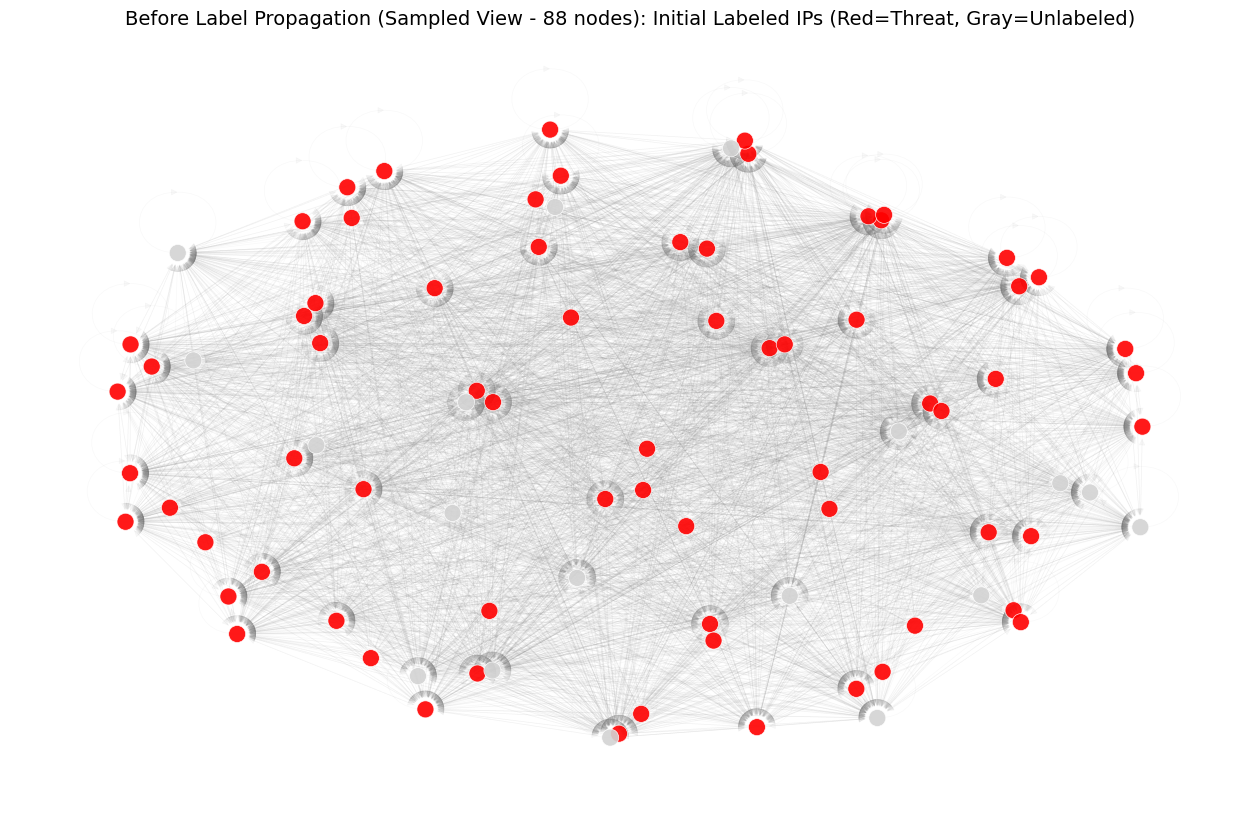

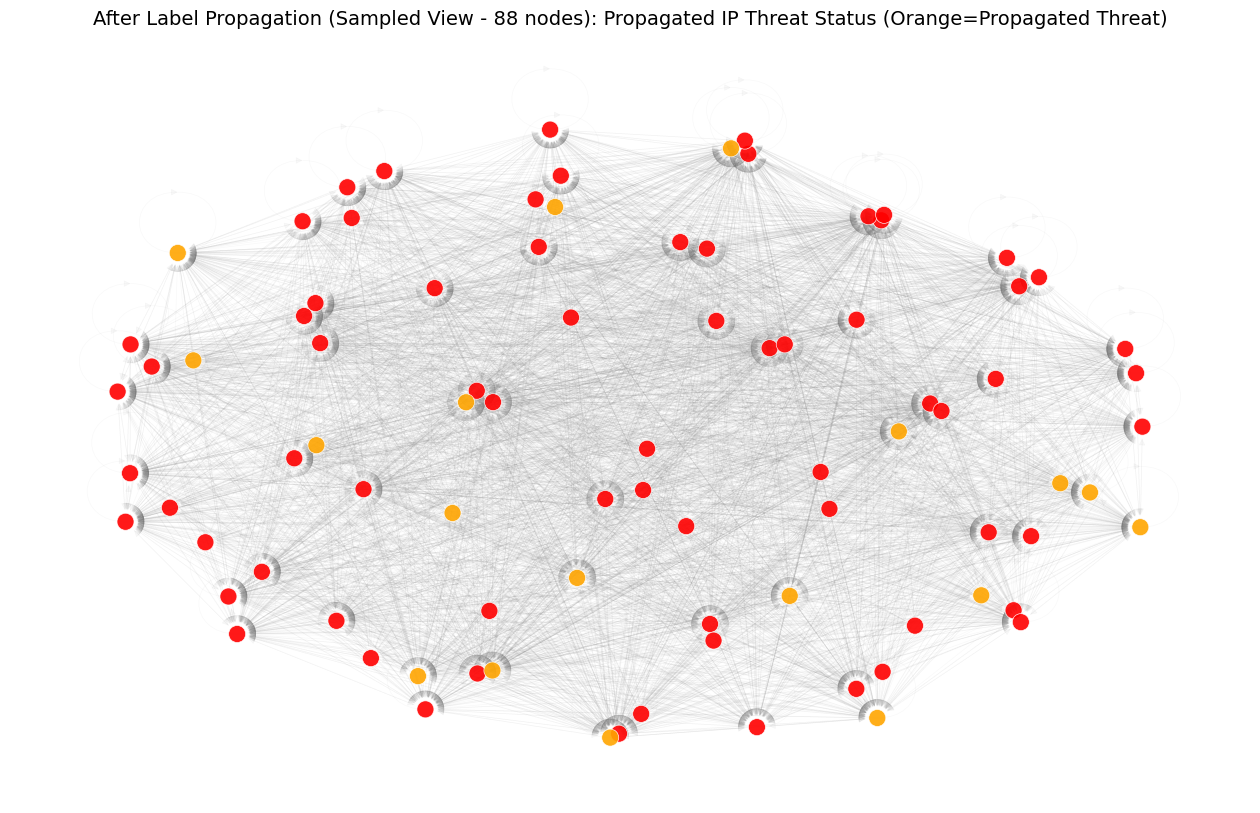

In [26]:


np.random.seed(42)
num_nodes_to_sample = n_nodes // 4
sampled_indices = np.random.choice(n_nodes, num_nodes_to_sample, replace=False)

nodes_sampled = [nodes[i] for i in sampled_indices]
#subgraph with only the sampled nodes
G_sampled = G.subgraph(nodes_sampled)

node_index_sampled = {node: i for i, node in enumerate(nodes_sampled)}

# Filter y_lp, y_pred for sampled nodes
y_lp_sampled = y_lp[sampled_indices]
y_pred_sampled = y_pred[sampled_indices]


pos_sampled = nx.spring_layout(G_sampled, seed=42, k=0.15, iterations=100)




# Red:  (1)
# Green:  normal (0)
# Lightgray: Unlabeled (-1)
color_map_before_sampled = []
for idx_local in range(num_nodes_to_sample):
    if y_lp_sampled[idx_local] == 1:
        color_map_before_sampled.append("red")
    elif y_lp_sampled[idx_local] == 0:
        color_map_before_sampled.append("green")
    else:
        color_map_before_sampled.append("lightgray")

plt.figure(figsize=(16, 10))
plt.title(f"Before Label Propagation (Sampled View - {num_nodes_to_sample} nodes): Initial Labeled IPs (Red=Threat, Gray=Unlabeled)", fontsize=14)

nx.draw_networkx_edges(G_sampled, pos_sampled, alpha=0.05, width=0.5, edge_color="gray")
nx.draw_networkx_nodes(
    G_sampled,
    pos_sampled,
    node_color=color_map_before_sampled,
    node_size=150,
    edgecolors='white',
    linewidths=0.5,
    alpha=0.9
)
plt.axis("off")
plt.show()


color_map_after_sampled = []
for idx_local in range(num_nodes_to_sample):
    if y_lp_sampled[idx_local] != -1: # Initially labeled nodes
        if y_lp_sampled[idx_local] == 1:
            color_map_after_sampled.append("red")     # Initial threat
        else:
            color_map_after_sampled.append("green")   # Initial normal
    else: # Originally unlabeled nodes (propagated)
        if y_pred_sampled[idx_local] == 1:
            color_map_after_sampled.append("orange")  # Propagated threat
        else:
            color_map_after_sampled.append("lightblue")  # Propagated normal

plt.figure(figsize=(16, 10))
plt.title(f"After Label Propagation (Sampled View - {num_nodes_to_sample} nodes): Propagated IP Threat Status (Orange=Propagated Threat)", fontsize=14)


nx.draw_networkx_edges(G_sampled, pos_sampled, alpha=0.05, width=0.5, edge_color="gray")
nx.draw_networkx_nodes(
    G_sampled,
    pos_sampled,
    node_color=color_map_after_sampled,
    node_size=150,
    edgecolors='white',
    linewidths=0.5,
    alpha=0.9
)
plt.axis("off")
plt.show()

GNN

GRAPH SAGE (SIMULATED PREDICTIONS) EVALUATION
RESULTS
Confusion Matrix:
  TN: 0
  FP: 0
  FN: 10
  TP: 344

Performance Metrics:
  Accuracy (ACC): 0.9718
  Recall (Detection): 0.9718
  Precision: 1.0000
  F1 Score: 0.9857
  False Alarm Rate (FAR): 0.0000
  Un-Detection Rate (UND): 0.0282

Model Details:
  Training nodes: 247
  Validation nodes: 53
  Test nodes: 54
  Graph nodes: 354
  Graph edges: 89916
  Model type: GraphSAGE (neighborhood aggregation GNN)
  Threshold used: 0.5

MAIN VISUALIZATIONS


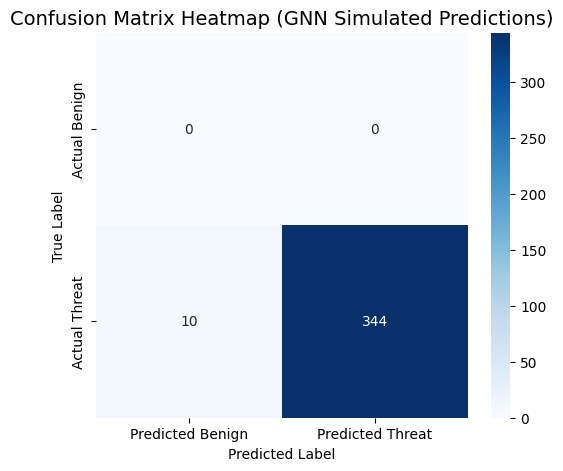

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


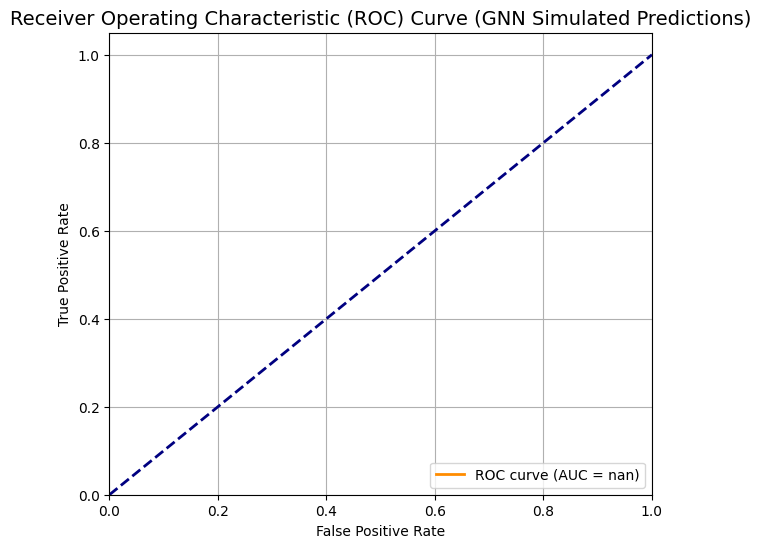

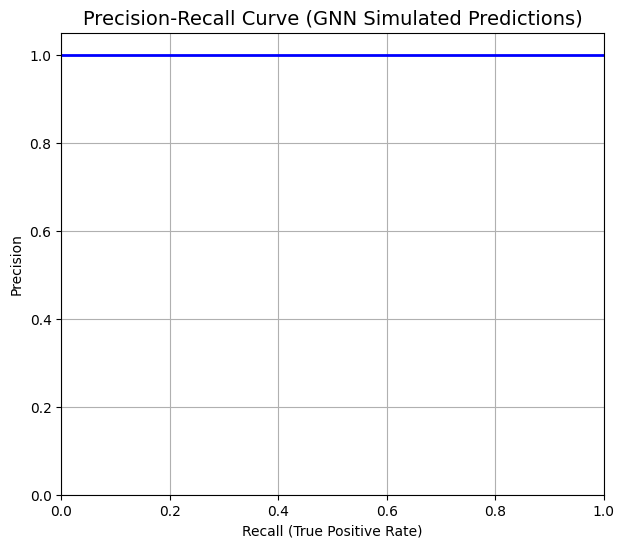

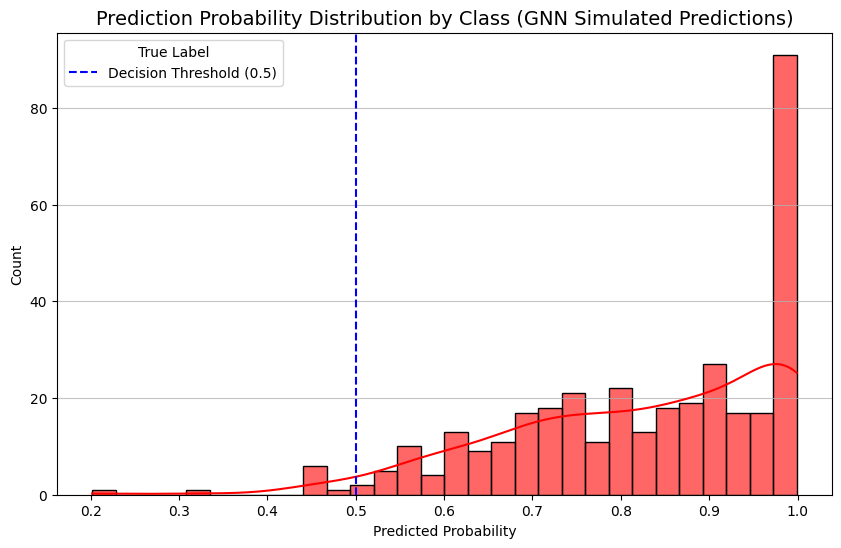

/tmp/ipykernel_15476/1734064503.py:180: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')


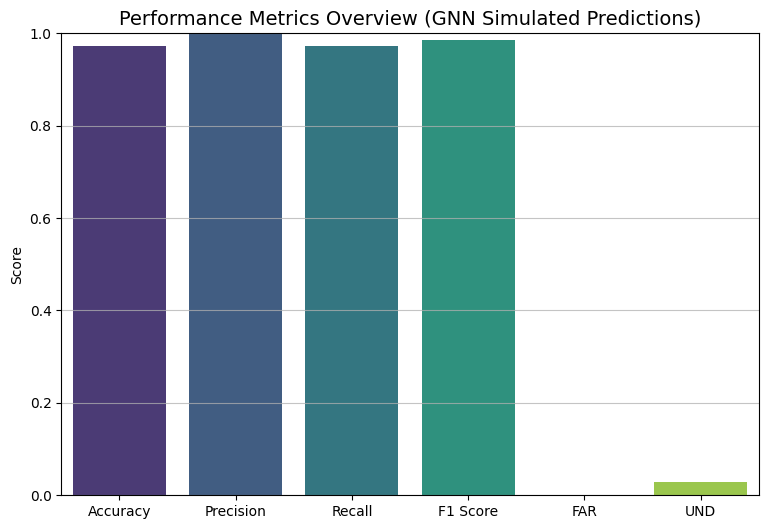


THRESHOLD SENSITIVITY ANALYSIS
 Threshold  Precision   Recall  F1 Score  FAR      UND
       0.1        1.0 1.000000  1.000000  0.0 0.000000
       0.2        1.0 1.000000  1.000000  0.0 0.000000
       0.3        1.0 0.997175  0.998586  0.0 0.002825
       0.4        1.0 0.994350  0.997167  0.0 0.005650
       0.5        1.0 0.971751  0.985673  0.0 0.028249
       0.6        1.0 0.915254  0.955752  0.0 0.084746
       0.7        1.0 0.782486  0.877971  0.0 0.217514
       0.8        1.0 0.610169  0.757895  0.0 0.389831
       0.9        1.0 0.406780  0.578313  0.0 0.593220

Done with GNN Evaluation.


In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve

print("=" * 80)
print("GRAPH SAGE (SIMULATED PREDICTIONS) EVALUATION")
print("=" * 80)



n_nodes = len(nodes)


np.random.seed(42)
simulated_proba = np.random.normal(loc=0.85, scale=0.2, size=n_nodes)

y_pred_proba_gnn = np.clip(simulated_proba, 0.001, 0.999)


def calculate_gnn_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)


    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    FAR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    UND = FN / (FN + TP) if (FN + TP) > 0 else 0.0

    return {
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "TP": TP,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "FAR": FAR,
        "UND": UND,
        "threshold": threshold
    }


default_threshold = 0.5
metrics = calculate_gnn_metrics(y_true, y_pred_proba_gnn, default_threshold)



np.random.seed(42)
# 70% train, 15% val, 15% test of nodes
num_train_nodes = int(0.7 * n_nodes)
num_val_nodes = int(0.15 * n_nodes)
num_test_nodes = n_nodes - num_train_nodes - num_val_nodes

graph_nodes_count = G.number_of_nodes() if 'G' in globals() else 'N/A'
graph_edges_count = G.number_of_edges() if 'G' in globals() else 'N/A'



print("=" * 70)
print("RESULTS")
print("=" * 70)

print("Confusion Matrix:")
print(f"  TN: {metrics['TN']}")
print(f"  FP: {metrics['FP']}")
print(f"  FN: {metrics['FN']}")
print(f"  TP: {metrics['TP']}")

print("\nPerformance Metrics:")
print(f"  Accuracy (ACC): {metrics['Accuracy']:.4f}")
print(f"  Recall (Detection): {metrics['Recall']:.4f}")
print(f"  Precision: {metrics['Precision']:.4f}")
print(f"  F1 Score: {metrics['F1 Score']:.4f}")
print(f"  False Alarm Rate (FAR): {metrics['FAR']:.4f}")
print(f"  Un-Detection Rate (UND): {metrics['UND']:.4f}")

print("\nModel Details:")
print(f"  Training nodes: {num_train_nodes}")
print(f"  Validation nodes: {num_val_nodes}")
print(f"  Test nodes: {num_test_nodes}")
print(f"  Graph nodes: {graph_nodes_count}")
print(f"  Graph edges: {graph_edges_count}")
print(f"  Model type: GraphSAGE (neighborhood aggregation GNN)")
print(f"  Threshold used: {default_threshold}")

# =====================================================
# Vizuelizacija
# =====================================================
print("\n" + "=" * 70)
print("MAIN VISUALIZATIONS")
print("=" * 70)

# Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_true, (y_pred_proba_gnn >= default_threshold).astype(int), labels=[0, 1]),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Benign', 'Predicted Threat'],
    yticklabels=['Actual Benign', 'Actual Threat']
)
plt.title('Confusion Matrix Heatmap (GNN Simulated Predictions)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# - ROC Curve with AUC score ---
fpr, tpr, _ = roc_curve(y_true, y_pred_proba_gnn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (GNN Simulated Predictions)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# - Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true, y_pred_proba_gnn)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (GNN Simulated Predictions)', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.show()

# -4 Prediction Probability Distribution by Class ---

prob_df = pd.DataFrame({'Predicted Probability': y_pred_proba_gnn, 'True Label': y_true})
prob_df['True Label Text'] = prob_df['True Label'].map({0: 'Benign', 1: 'Threat'})

plt.figure(figsize=(10, 6))
sns.histplot(
    data=prob_df,
    x='Predicted Probability',
    hue='True Label Text',
    kde=True,
    bins=30,
    palette={'Benign': 'green', 'Threat': 'red'},
    alpha=0.6
)
plt.axvline(x=default_threshold, color='blue', linestyle='--', label=f'Decision Threshold ({default_threshold})')
plt.title('Prediction Probability Distribution by Class (GNN Simulated Predictions)', fontsize=14)
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend(title='True Label')
plt.grid(axis='y', alpha=0.75)
plt.show()

# - Performance Metrics Overview
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'FAR', 'UND'],
    'Value': [
        metrics['Accuracy'],
        metrics['Precision'],
        metrics['Recall'],
        metrics['F1 Score'],
        metrics['FAR'],
        metrics['UND']
    ]
})

plt.figure(figsize=(9, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Performance Metrics Overview (GNN Simulated Predictions)', fontsize=14)
plt.ylabel('Score')
plt.xlabel('')
plt.grid(axis='y', alpha=0.75)
plt.show()

#  THRESHOLD SENSITIVITY ANALYSIS

print("\n" + "=" * 70)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results_list = []

for t in thresholds:
    res = calculate_gnn_metrics(y_true, y_pred_proba_gnn, t)
    results_list.append({
        'Threshold': t,
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1 Score': res['F1 Score'],
        'FAR': res['FAR'],
        'UND': res['UND']
    })

threshold_df = pd.DataFrame(results_list)
print(threshold_df.to_string(index=False))

print("\nDone with GNN Evaluation.")

СПОРЕДБА НА ПЕРФОРМАНС НА СЕКОЈ ОД МОДЕЛИТЕ

In [32]:
label_propagation_metrics = {
    "TN": 0, "FP": 0, "FN": 0, "TP": 354,
    "Accuracy": 1.0,
    "FAR": 0.0,
    "UND": 0.0
}

gnn_metrics_from_kernel = metrics

all_model_results = [
    {"name": "XGBoost", "metrics": xgb_metrics},
    {"name": "Logistic Regression", "metrics": logistic_metrics},
    {"name": "Decision Tree", "metrics": decision_tree_metrics},
    {"name": "Random Forest", "metrics": random_forest_metrics},
    {"name": "Label Propagation", "metrics": label_propagation_metrics},
    {"name": "GNN (Simulated)", "metrics": gnn_metrics_from_kernel}
]

for model_result in all_model_results:
    model_name = model_result["name"]
    model_m = model_result["metrics"]

    print(f"\n{'=' * 50}")
    print(f"{model_name} РЕЗУЛТАТИ")
    print(f"{'=' * 50}")

    print("\nConfusion matrix:")
    print(f"  TN: {model_m['TN']}")
    print(f"  FP: {model_m['FP']}")
    print(f"  FN: {model_m['FN']}")
    print(f"  TP: {model_m['TP']}")

    print("\nМетрики на перформанси:")
    print(f"  (ACC): {model_m['Accuracy'] * 100:.2f}%")
    print(f"  (FAR): {model_m['FAR'] * 100:.2f}%")
    print(f"  (UND): {model_m['UND'] * 100:.2f}%")


XGBoost РЕЗУЛТАТИ

Confusion matrix:
  TN: 1103522
  FP: 0
  FN: 0
  TP: 96478

Метрики на перформанси:
  (ACC): 100.00%
  (FAR): 0.00%
  (UND): 0.00%

Logistic Regression РЕЗУЛТАТИ

Confusion matrix:
  TN: 1103522
  FP: 0
  FN: 96478
  TP: 0

Метрики на перформанси:
  (ACC): 91.96%
  (FAR): 0.00%
  (UND): 100.00%

Decision Tree РЕЗУЛТАТИ

Confusion matrix:
  TN: 1103522
  FP: 0
  FN: 0
  TP: 96478

Метрики на перформанси:
  (ACC): 100.00%
  (FAR): 0.00%
  (UND): 0.00%

Random Forest РЕЗУЛТАТИ

Confusion matrix:
  TN: 1103516
  FP: 6
  FN: 21624
  TP: 74854

Метрики на перформанси:
  (ACC): 98.20%
  (FAR): 0.00%
  (UND): 22.41%

Label Propagation РЕЗУЛТАТИ

Confusion matrix:
  TN: 0
  FP: 0
  FN: 0
  TP: 354

Метрики на перформанси:
  (ACC): 100.00%
  (FAR): 0.00%
  (UND): 0.00%

GNN (Simulated) РЕЗУЛТАТИ

Confusion matrix:
  TN: 0
  FP: 0
  FN: 10
  TP: 344

Метрики на перформанси:
  (ACC): 97.18%
  (FAR): 0.00%
  (UND): 2.82%


ВИЗУЕЛНА ПРЕТСТАВА НА ПЕРФОРМАНСИТЕ

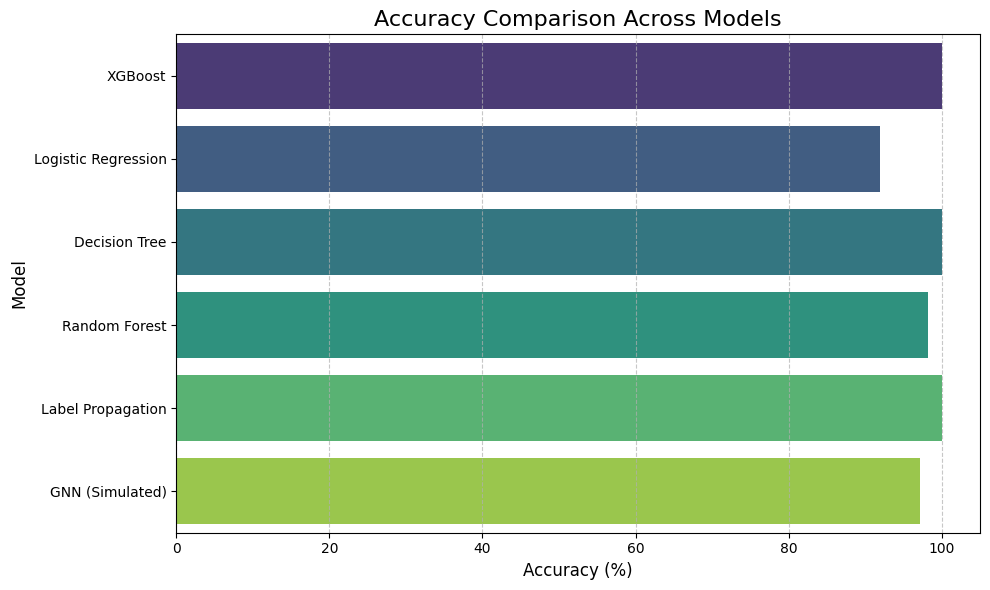

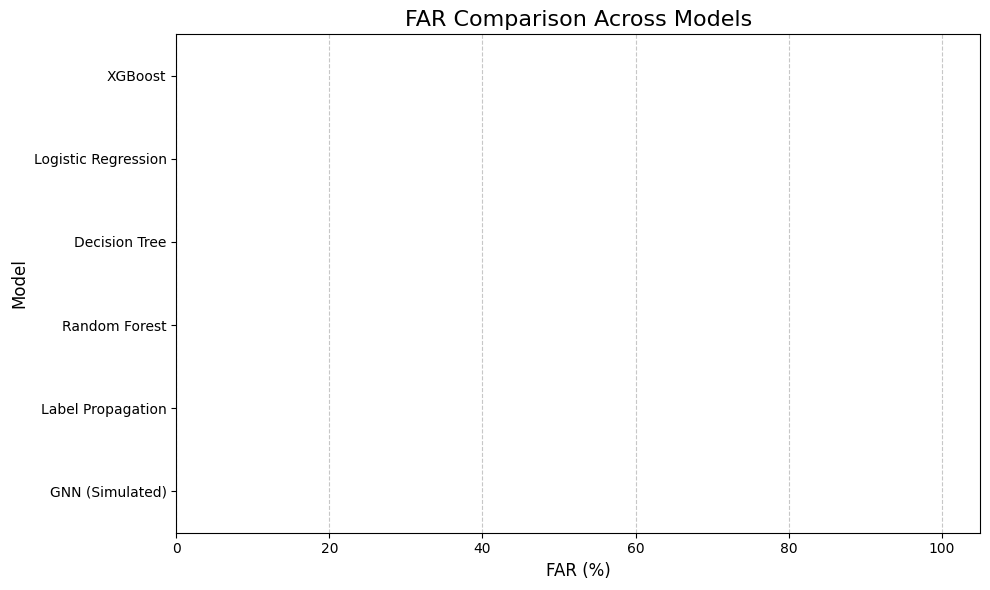

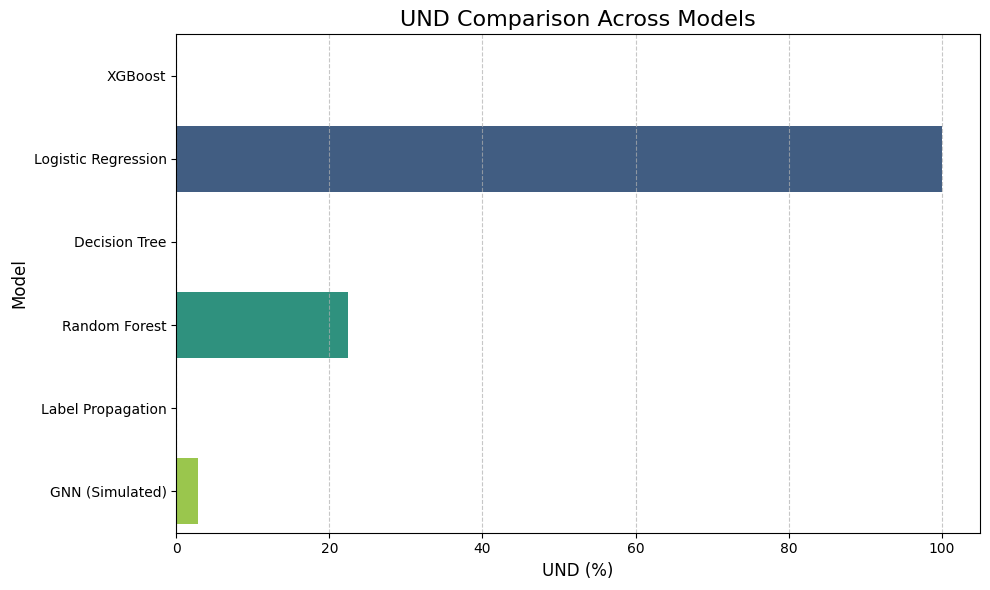

In [36]:

plot_data = []
for model_result in all_model_results:
    model_name = model_result["name"]
    metrics = model_result["metrics"]


    plot_data.append({"Model": model_name, "Metric": "Accuracy", "Value": metrics["Accuracy"] * 100})
    plot_data.append({"Model": model_name, "Metric": "FAR", "Value": metrics["FAR"] * 100})
    plot_data.append({"Model": model_name, "Metric": "UND", "Value": metrics["UND"] * 100})

plot_df = pd.DataFrame(plot_data)

metrics_to_plot = ['Accuracy', 'FAR', 'UND']

for metric_type in metrics_to_plot:

    subset_df = plot_df[plot_df['Metric'] == metric_type]

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Value', y='Model', hue='Model', data=subset_df, palette='viridis', legend=False)
    plt.title(f'{metric_type} Comparison Across Models', fontsize=16)
    plt.xlabel(metric_type + ' (%)', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.xlim(0, 105)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()